# Sign Language MNIST – Full ML Exploration
### Models covered: Logistic Regression · MLP · SimpleCNN · DeepCNN · ResNetSmall · CNN+LSTM
### Experiments: Architecture comparison · LR search · Regularisation · Batch size · Best config
---
Run cells **top to bottom**. All figures are saved to `./figures/`.

In [9]:

# ============================================================
# CELL 1 – Imports & global setup
# Run this cell FIRST every session
# ============================================================
import os, time
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

os.makedirs("figures", exist_ok=True)

# Label map: dataset uses 0-25 but skips 9=J and 25=Z (motion gestures)
LABEL_MAP = {i: chr(65 + i) for i in range(26) if i not in (9, 25)}
print(f"Classes: {list(LABEL_MAP.values())}")


Using device: cpu
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']


In [14]:

# ============================================================
# CELL 2 – Preprocessing helpers
# Must run before any model or EDA cell
# ============================================================

def normalise(X):
    """Scale pixel values from [0,255] → [0,1]."""
    return X / 255.0


def reshape_for_cnn(X):
    """Reshape flat (N, 784) array → (N, 1, 28, 28) for PyTorch CNNs."""
    return X.reshape(-1, 1, 28, 28)


class SignLangDataset(Dataset):
    """
    PyTorch Dataset wrapping numpy arrays.
    augment=True applies a random ±10° rotation per sample using
    affine_grid / grid_sample (no PIL dependency needed).
    Note: horizontal flip is intentionally excluded – in ASL, a mirrored
    hand can represent a *different* letter.
    """
    def __init__(self, X, y, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32)   # (N,1,28,28)
        self.y = torch.tensor(y, dtype=torch.long)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.augment:
            angle = (torch.rand(1).item() - 0.5) * 20   # uniform ±10 deg
            rad   = angle * np.pi / 180
            ca, sa = float(np.cos(rad)), float(np.sin(rad))
            theta = torch.tensor([[ca, -sa, 0.0],
                                   [sa,  ca, 0.0]], dtype=torch.float32)
            grid = F.affine_grid(theta.unsqueeze(0),
                                  x.unsqueeze(0).size(), align_corners=False)
            x = F.grid_sample(x.unsqueeze(0), grid,
                               align_corners=False,
                               padding_mode="border").squeeze(0)
        return x, self.y[idx]

def make_loaders(X_train, y_train, X_val, y_val, X_test, y_test, batch_size=64, augment=False):
    """Build train, val, and test DataLoaders."""
    train_ds = SignLangDataset(reshape_for_cnn(X_train), y_train, augment)
    val_ds   = SignLangDataset(reshape_for_cnn(X_val),   y_val,   False)
    test_ds  = SignLangDataset(reshape_for_cnn(X_test),  y_test,  False)
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=256,        shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=256,        shuffle=False, num_workers=0)
    
    return train_loader, val_loader, test_loader



print("Preprocessing helpers defined ✓")


Preprocessing helpers defined ✓


In [15]:

# ============================================================
# CELL 3 – Load Data
# Update paths if your CSVs are in a different folder
# ============================================================
TRAIN_CSV = "sign_mnist_train.csv"
TEST_CSV  = "sign_mnist_test.csv"

train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

y_train_raw = train_df["label"].values
X_train_raw = train_df.drop("label", axis=1).values.astype(np.float32)

y_test_raw  = test_df["label"].values
X_test_raw  = test_df.drop("label", axis=1).values.astype(np.float32)

print(f"Train: {X_train_raw.shape}  |  Test: {X_test_raw.shape}")
print(f"Unique labels: {sorted(np.unique(y_train_raw))}")
print(f"Pixels per sample: {X_train_raw.shape[1]}  (28×28 = 784)")

# ── Remap original labels (0-25, gaps at 9 and 25) → contiguous 0-23 ────────
# This is required for PyTorch's CrossEntropyLoss and sklearn
unique_labels = sorted(np.unique(y_train_raw))
label_remap   = {old: new for new, old in enumerate(unique_labels)}
LABEL_MAP_R   = {new: LABEL_MAP[old] for old, new in label_remap.items()}

y_train = np.array([label_remap[y] for y in y_train_raw])
y_test  = np.array([label_remap[y] for y in y_test_raw])

X_train_n = normalise(X_train_raw)
X_test_n  = normalise(X_test_raw)

# Add this to CELL 3, right before the print statements at the end
from sklearn.model_selection import train_test_split

# Split training data into train (85%) and validation (15%)
X_train_n, X_val_n, y_train, y_val = train_test_split(
    X_train_n, y_train, 
    test_size=0.15, 
    random_state=SEED, 
    stratify=y_train  # Maintain class distribution
)

print(f"After split: Train: {X_train_n.shape[0]}, Val: {X_val_n.shape[0]}, Test: {X_test_n.shape[0]}")

NUM_CLASSES = len(unique_labels)  # 24
print(f"\nAfter remapping: {NUM_CLASSES} classes (0–{NUM_CLASSES-1})")
print(f"Label map sample: {dict(list(LABEL_MAP_R.items())[:5])} …")




Train: (27455, 784)  |  Test: (7172, 784)
Unique labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
Pixels per sample: 784  (28×28 = 784)
After split: Train: 23336, Val: 4119, Test: 7172

After remapping: 24 classes (0–23)
Label map sample: {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E'} …


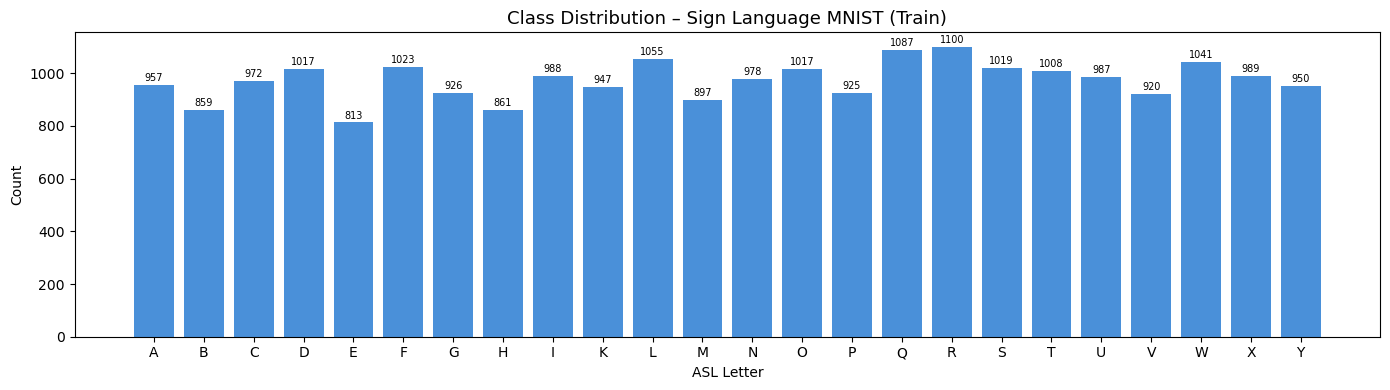

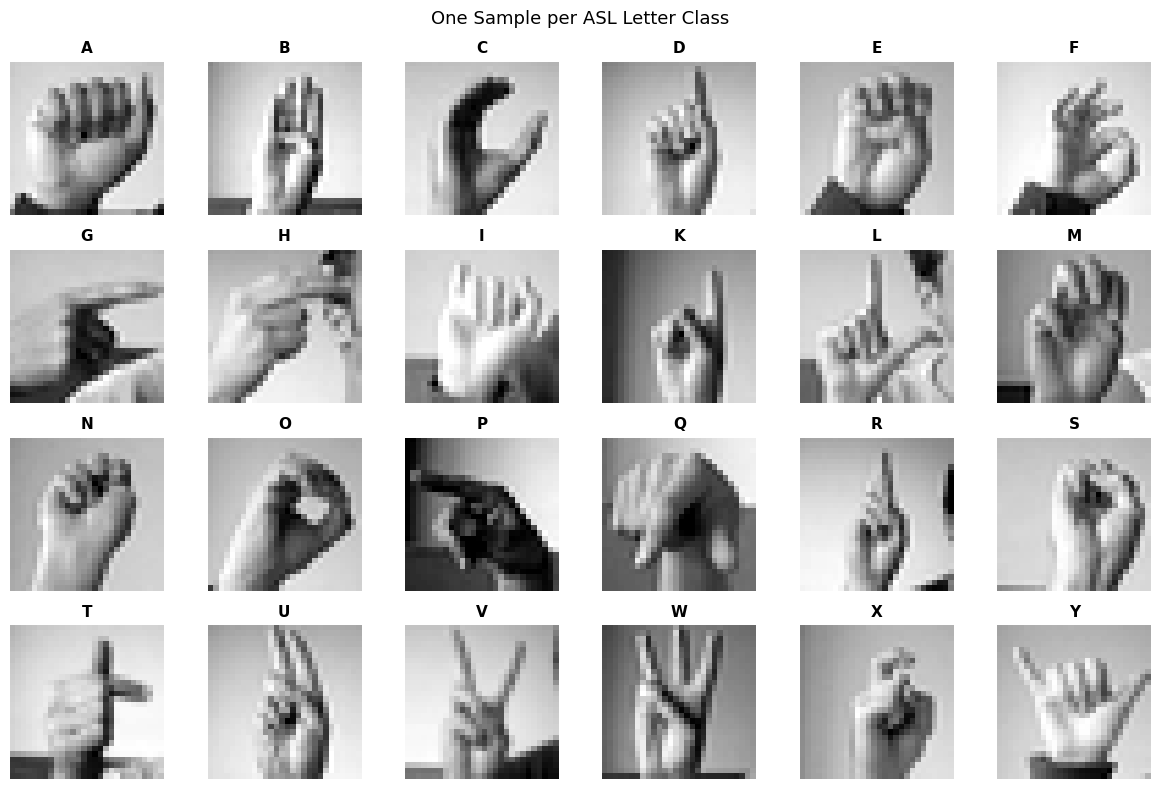

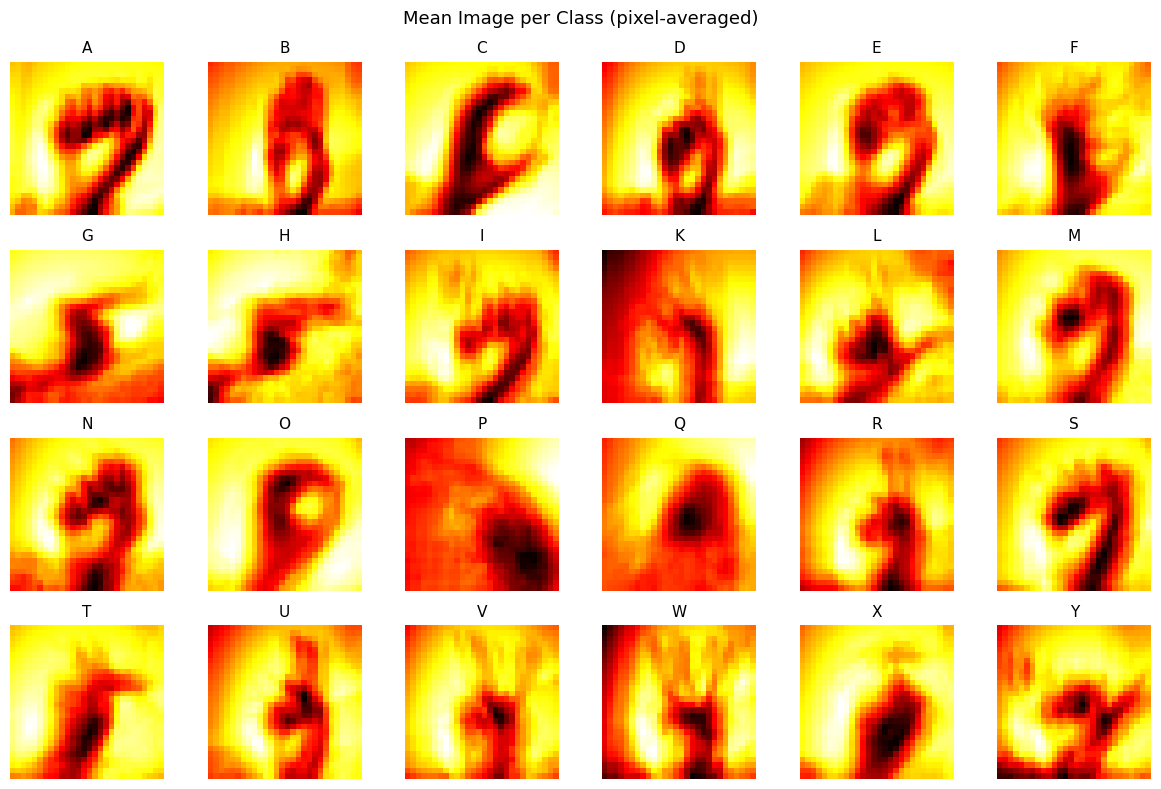

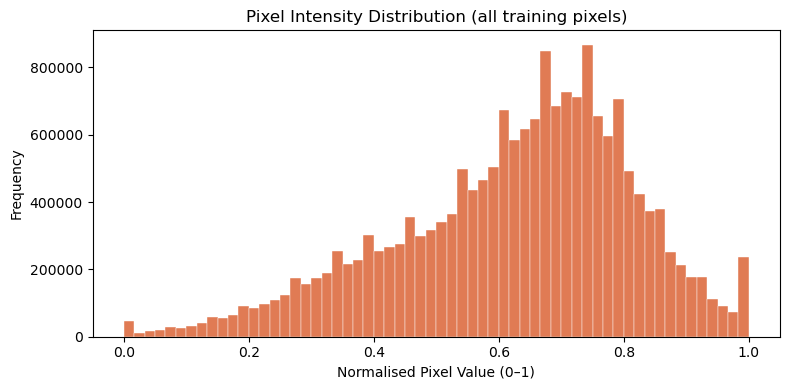

Computing PCA …


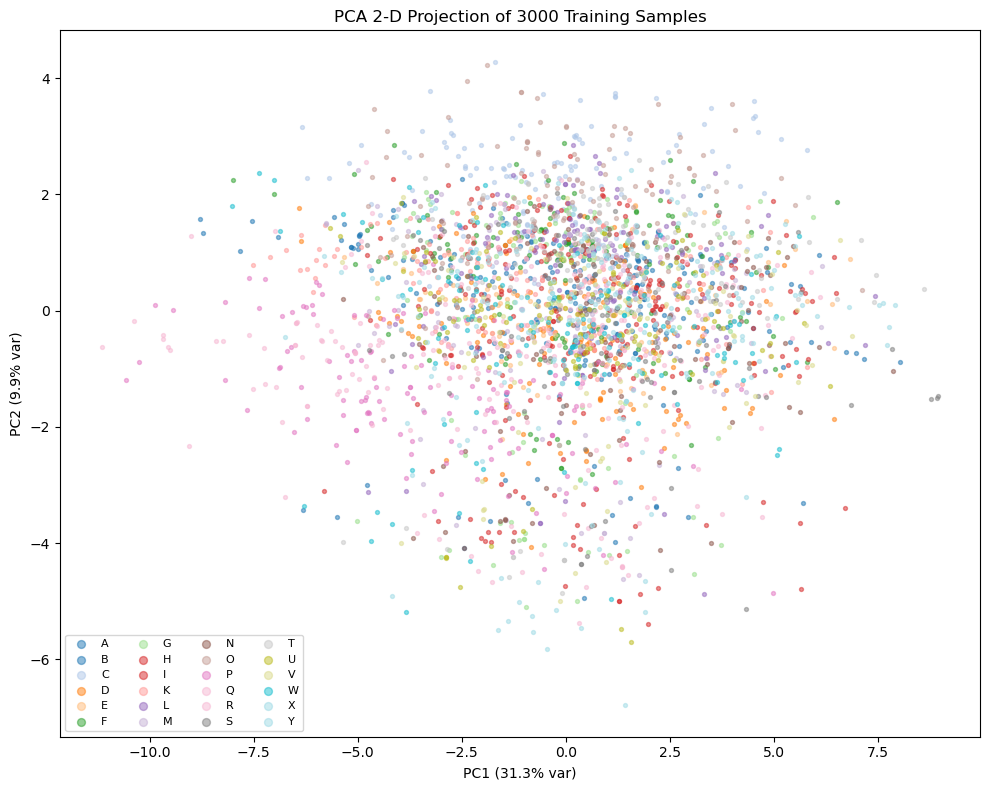

EDA done ✓


In [16]:

# ============================================================
# CELL 4 – Exploratory Data Analysis
# ============================================================
classes = sorted(np.unique(y_train))

# ── 4a. Class distribution ───────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
counts = pd.Series(y_train).value_counts().sort_index()
ax.bar([LABEL_MAP_R[c] for c in counts.index], counts.values, color="#4a90d9")
ax.set_title("Class Distribution – Sign Language MNIST (Train)", fontsize=13)
ax.set_xlabel("ASL Letter"); ax.set_ylabel("Count")
for i, (_, cnt) in enumerate(counts.items()):
    ax.text(i, cnt + 15, str(cnt), ha="center", fontsize=7)
plt.tight_layout()
plt.savefig("figures/01_class_distribution.png", dpi=120); plt.show()

# ── 4b. One sample per class ─────────────────────────────────
fig, axes = plt.subplots(4, 6, figsize=(12, 8))
for idx, cls in enumerate(classes):
    img = X_train_n[y_train == cls][0].reshape(28, 28)
    axes.flat[idx].imshow(img, cmap="gray")
    axes.flat[idx].set_title(LABEL_MAP_R[cls], fontweight="bold", fontsize=11)
    axes.flat[idx].axis("off")
for j in range(len(classes), len(axes.flat)):
    axes.flat[j].axis("off")
fig.suptitle("One Sample per ASL Letter Class", fontsize=13)
plt.tight_layout(); plt.savefig("figures/02_sample_images.png", dpi=120); plt.show()

# ── 4c. Mean image per class ─────────────────────────────────
fig, axes = plt.subplots(4, 6, figsize=(12, 8))
for idx, cls in enumerate(classes):
    mean_img = X_train_n[y_train == cls].mean(axis=0).reshape(28, 28)
    axes.flat[idx].imshow(mean_img, cmap="hot")
    axes.flat[idx].set_title(LABEL_MAP_R[cls], fontsize=11)
    axes.flat[idx].axis("off")
for j in range(len(classes), len(axes.flat)):
    axes.flat[j].axis("off")
fig.suptitle("Mean Image per Class (pixel-averaged)", fontsize=13)
plt.tight_layout(); plt.savefig("figures/03_mean_images.png", dpi=120); plt.show()

# ── 4d. Pixel intensity histogram ───────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(X_train_n.flatten(), bins=60, color="#e07b54", edgecolor="white", lw=0.3)
ax.set_title("Pixel Intensity Distribution (all training pixels)")
ax.set_xlabel("Normalised Pixel Value (0–1)"); ax.set_ylabel("Frequency")
plt.tight_layout(); plt.savefig("figures/04_pixel_histogram.png", dpi=120); plt.show()

# ── 4e. PCA 2-D scatter ──────────────────────────────────────
print("Computing PCA …")
pca = PCA(n_components=2, random_state=SEED)
idx_samp = np.random.choice(len(X_train_n), 3000, replace=False)
X_pca    = pca.fit_transform(X_train_n[idx_samp])
y_samp   = y_train[idx_samp]

fig, ax = plt.subplots(figsize=(10, 8))
cmap = matplotlib.colormaps.get_cmap("tab20").resampled(NUM_CLASSES)
for i, cls in enumerate(classes):
    m = y_samp == cls
    ax.scatter(X_pca[m, 0], X_pca[m, 1], s=8, alpha=0.5,
               color=cmap(i), label=LABEL_MAP_R[cls])
ax.legend(markerscale=2, fontsize=8, ncol=4)
ax.set_title("PCA 2-D Projection of 3000 Training Samples")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.tight_layout(); plt.savefig("figures/05_pca_scatter.png", dpi=120); plt.show()
print("EDA done ✓")


In [13]:

# ============================================================
# CELL 5 – Plotting & evaluation helpers
# Must run before any training cell
# ============================================================

def plot_training_curves(history, model_name, save_path):
    """4-panel dashboard: loss, accuracy, LR schedule, overfitting gap."""
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"Training Curves – {model_name}", fontsize=13, fontweight="bold")

    ax = axes[0, 0]
    ax.plot(epochs, history["train_loss"], label="Train", color="#3a86ff")
    ax.plot(epochs, history["val_loss"],   label="Val",   color="#ff6b6b")
    ax.set_title("Cross-Entropy Loss"); ax.set_xlabel("Epoch")
    ax.legend(); ax.grid(alpha=0.3)

    ax = axes[0, 1]
    ax.plot(epochs, [a*100 for a in history["train_acc"]], label="Train", color="#3a86ff")
    ax.plot(epochs, [a*100 for a in history["val_acc"]],   label="Val",   color="#ff6b6b")
    ax.set_title("Accuracy (%)"); ax.set_xlabel("Epoch")
    ax.legend(); ax.grid(alpha=0.3)

    ax = axes[1, 0]
    ax.semilogy(epochs, history["lr"], color="#8338ec")
    ax.set_title("Learning Rate (log scale)"); ax.set_xlabel("Epoch"); ax.grid(alpha=0.3)

    gap = [(tr - vl)*100 for tr, vl in zip(history["train_acc"], history["val_acc"])]
    ax = axes[1, 1]
    ax.plot(epochs, gap, color="#fb5607")
    ax.axhline(0, color="black", ls="--", lw=0.8)
    ax.fill_between(epochs, 0, gap, alpha=0.2, color="#fb5607")
    ax.set_title("Overfitting Gap (Train − Val %)"); ax.set_xlabel("Epoch"); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=120); plt.show()


def plot_confusion_matrix(y_true, y_pred, title, save_path):
    """Normalised confusion matrix heatmap."""
    cls = sorted(np.unique(y_true))
    letters = [LABEL_MAP_R[c] for c in cls]
    cm = confusion_matrix(y_true, y_pred, labels=cls).astype(float)
    cm /= cm.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=letters, yticklabels=letters,
                linewidths=0.3, ax=ax, vmin=0, vmax=1)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.tight_layout(); plt.savefig(save_path, dpi=120); plt.show()


def plot_per_class_accuracy(y_true, y_pred, title, save_path):
    """Bar chart of per-class accuracy with colour coding."""
    cls = sorted(np.unique(y_true))
    letters = [LABEL_MAP_R[c] for c in cls]
    accs = [(y_pred[y_true==c] == y_true[y_true==c]).mean()*100 for c in cls]
    colors = ["#2ecc71" if a >= 90 else "#f39c12" if a >= 70 else "#e74c3c" for a in accs]
    fig, ax = plt.subplots(figsize=(14, 5))
    bars = ax.bar(letters, accs, color=colors, edgecolor="white", lw=0.5)
    ax.axhline(np.mean(accs), color="black", ls="--", label=f"Mean {np.mean(accs):.1f}%")
    ax.set_ylim(0, 108); ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("ASL Letter"); ax.set_ylabel("Accuracy (%)"); ax.legend()
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x()+bar.get_width()/2, acc+1, f"{acc:.0f}",
                ha="center", va="bottom", fontsize=8)
    plt.tight_layout(); plt.savefig(save_path, dpi=120); plt.show()


def visualise_conv_filters(model, save_path):
    """Display the learned first-layer filters (what edges/textures the CNN detects)."""
    first_conv = next((m for m in model.modules() if isinstance(m, nn.Conv2d)), None)
    if first_conv is None: return
    w = first_conv.weight.data.cpu().numpy()
    n = min(w.shape[0], 32)
    cols, rows = 8, (n + 7) // 8
    fig, axes = plt.subplots(rows, cols, figsize=(cols*1.5, rows*1.5))
    for i, ax in enumerate(axes.flat):
        if i < n:
            f = w[i, 0]; f = (f - f.min()) / (f.max() - f.min() + 1e-8)
            ax.imshow(f, cmap="gray")
        ax.axis("off")
    fig.suptitle("Learned 1st-Layer Conv Filters", fontsize=11)
    plt.tight_layout(); plt.savefig(save_path, dpi=120); plt.show()


def plot_hyperparameter_experiment(exp_results, param_name, save_path):
    """Line+scatter plot: hyperparameter value vs best val accuracy."""
    vals = list(exp_results.keys())
    accs = [v*100 for v in exp_results.values()]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(range(len(vals)), accs, marker="o", color="#3a86ff", lw=2, ms=8)
    ax.set_xticks(range(len(vals))); ax.set_xticklabels([str(v) for v in vals])
    ax.set_title(f"Hyperparameter Experiment: {param_name}", fontsize=12)
    ax.set_xlabel(param_name); ax.set_ylabel("Best Val Accuracy (%)"); ax.grid(alpha=0.3)
    for x, acc in enumerate(accs):
        ax.annotate(f"{acc:.1f}%", (x, acc), textcoords="offset points",
                    xytext=(0, 8), ha="center", fontsize=9)
    plt.tight_layout(); plt.savefig(save_path, dpi=120); plt.show()


def plot_multi_model_comparison(results_dict, save_path):
    """Final bar chart comparing all model/experiment accuracies."""
    names = list(results_dict.keys())
    accs  = [v*100 for v in results_dict.values()]
    colors = matplotlib.colormaps["viridis"](np.linspace(0.2, 0.85, len(names)))
    fig, ax = plt.subplots(figsize=(max(10, len(names)*0.9), 6))
    bars = ax.bar(names, accs, color=colors, edgecolor="white", lw=0.5)
    ax.axhline(max(accs), color="red", ls="--", alpha=0.5, label=f"Best {max(accs):.1f}%")
    ax.set_ylim(0, 108); ax.set_title("Test Accuracy – All Models & Experiments",
                                       fontsize=13, fontweight="bold")
    ax.set_ylabel("Test Accuracy (%)"); plt.xticks(rotation=38, ha="right", fontsize=8)
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x()+bar.get_width()/2, acc+0.5, f"{acc:.1f}%",
                ha="center", va="bottom", fontsize=7)
    ax.legend(); plt.tight_layout()
    plt.savefig(save_path, dpi=120); plt.show()


print("Plotting helpers defined ✓")


Plotting helpers defined ✓


In [17]:

# ============================================================
# CELL 6 – Training utilities (loss, train loop, evaluate)
# ============================================================

class LabelSmoothingLoss(nn.Module):
    """
    Soft cross-entropy loss.
    Instead of pushing the correct logit to +∞, it targets
    (1 - ε) for the true class and ε/(K-1) for all others.
    Prevents overconfident predictions → better generalisation.
    Reference: Szegedy et al. 'Rethinking the Inception Architecture' (2016).
    """
    def __init__(self, num_classes, smoothing=0.1):
        super().__init__()
        self.eps = smoothing
        self.K   = num_classes

    def forward(self, pred, target):
        conf = 1.0 - self.eps
        soft = self.eps / (self.K - 1)
        one_hot = torch.zeros_like(pred).scatter_(1, target.unsqueeze(1), 1)
        soft_target = one_hot * conf + (1 - one_hot) * soft
        return -(soft_target * F.log_softmax(pred, dim=1)).sum(dim=1).mean()


def train_one_epoch(model, loader, opt, criterion, device):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        logits = model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        opt.step()
        total_loss += loss.item() * len(yb)
        correct    += (logits.argmax(1) == yb).sum().item()
        n          += len(yb)
    return total_loss / n, correct / n


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            total_loss += criterion(logits, yb).item() * len(yb)
            correct    += (logits.argmax(1) == yb).sum().item()
            n          += len(yb)
    return total_loss / n, correct / n


def get_predictions(model, loader, device):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            preds.extend(model(xb.to(device)).argmax(1).cpu().numpy())
            trues.extend(yb.numpy())
    return np.array(preds), np.array(trues)


def train_model(model, train_loader, val_loader, opt, criterion,
                scheduler, num_epochs, device, name="model"):
    """
    Full training loop.
    - Tracks train/val loss and accuracy each epoch
    - Saves best weights (by val accuracy) and restores them at the end
    - Supports both ReduceLROnPlateau and other schedulers
    """
    history = {k: [] for k in ["train_loss","val_loss","train_acc","val_acc","lr"]}
    best_acc, best_state = 0.0, None
    print(f"\n  Training [{name}] for {num_epochs} epochs on {device} …")

    for epoch in range(1, num_epochs + 1):
        tl, ta = train_one_epoch(model, train_loader, opt, criterion, device)
        vl, va = evaluate(model, val_loader, criterion, device)
        lr_now = opt.param_groups[0]["lr"]

        for k, v in zip(history, [tl, vl, ta, va, lr_now]):
            history[k].append(v)

        if va > best_acc:
            best_acc   = va
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(vl)
            else:
                scheduler.step()

        if epoch % 5 == 0 or epoch == 1:
            print(f"    Ep {epoch:>3}/{num_epochs}  "
                  f"tr_loss={tl:.4f} tr_acc={ta*100:.1f}%  "
                  f"vl_loss={vl:.4f} vl_acc={va*100:.1f}%  lr={lr_now:.2e}")

    if best_state:
        model.load_state_dict(best_state)
    print(f"  → Best val acc: {best_acc*100:.2f}%")
    return history

def run_experiment(model, name, num_epochs=25, batch_size=64, lr=1e-3,
                   weight_decay=1e-4, label_smoothing=False,
                   cosine_lr=False, augment=False):
    """
    Convenience wrapper: builds loaders, optimiser, scheduler, criterion
    then trains the model and returns (trained_model, history, preds, true, test_acc).
    Now uses X_train_n, X_val_n, y_train, y_val, X_test_n, y_test (globals).
    """
    # Use the global validation set
    train_loader, val_loader, test_loader = make_loaders(
        X_train_n, y_train, X_val_n, y_val, X_test_n, y_test,
        batch_size=batch_size, augment=augment
    )
    
    model = model.to(DEVICE)
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    criterion = (LabelSmoothingLoss(NUM_CLASSES, 0.1)
                 if label_smoothing else nn.CrossEntropyLoss())

    if cosine_lr:
        sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=num_epochs, eta_min=1e-6)
    else:
        sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min",
                                                      factor=0.5, patience=4)

    # Train on train_loader, validate on val_loader
    hist = train_model(model, train_loader, val_loader,  # Changed: val_loader now
                         opt, criterion, sched, num_epochs, DEVICE, name)
    
    # Final evaluation on test_loader (never seen during training)
    preds, true = get_predictions(model, test_loader, DEVICE)
    acc = accuracy_score(true, preds)
    print(f"  Final TEST accuracy [{name}]: {acc*100:.2f}%")
    return model, hist, preds, true, acc


# Global dict to collect all results for final comparison
all_results = {}
print("Training utilities defined ✓")


Training utilities defined ✓


In [18]:
# ============================================================
# CELL 7 – sklearn Baselines (Logistic Regression + MLP)
# Now properly trained on train split, validated on val split
# ============================================================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train_n)  # Now using train split only
X_val_sc = scaler.transform(X_val_n)        # New: validation
X_te_sc = scaler.transform(X_test_n)

# ── Logistic Regression ──────────────────────────────────────
print("Fitting Logistic Regression …")
t0 = time.time()
lr_clf = LogisticRegression(max_iter=500, solver="saga", C=1.0,
                             random_state=SEED, n_jobs=-1)
lr_clf.fit(X_tr_sc, y_train)  # Train on train split
acc_lr_val = accuracy_score(y_val, lr_clf.predict(X_val_sc))
acc_lr_test = accuracy_score(y_test, lr_clf.predict(X_te_sc))
print(f"  Logistic Regression: val={acc_lr_val*100:.2f}%, test={acc_lr_test*100:.2f}% ({time.time()-t0:.0f}s)")
all_results["Logistic Regression"] = acc_lr_test

# ── MLP (sklearn) ────────────────────────────────────────────
print("Fitting MLP (512-256) …")
t0 = time.time()
mlp = MLPClassifier(hidden_layer_sizes=(512, 256), activation="relu",
                    max_iter=30, learning_rate_init=1e-3,
                    random_state=SEED, verbose=False)
mlp.fit(X_tr_sc, y_train)
acc_mlp_val = accuracy_score(y_val, mlp.predict(X_val_sc))
acc_mlp_test = accuracy_score(y_test, mlp.predict(X_te_sc))
print(f"  MLP (512-256): val={acc_mlp_val*100:.2f}%, test={acc_mlp_test*100:.2f}% ({time.time()-t0:.0f}s)")
all_results["MLP (512-256)"] = acc_mlp_test

print(f"\nBaseline summary (test acc): {all_results}")

Fitting Logistic Regression …


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  Logistic Regression: val=100.00%, test=70.40% (482s)
Fitting MLP (512-256) …
  MLP (512-256): val=100.00%, test=83.94% (17s)

Baseline summary (test acc): {'Logistic Regression': 0.7039877300613497, 'MLP (512-256)': 0.8393753485778026}


In [19]:

# ============================================================
# CELL 8 – CNN / Hybrid Model Definitions
# ============================================================

# ── Model A: SimpleCNN ───────────────────────────────────────────────────────
class SimpleCNN(nn.Module):
    """
    Two convolutional blocks followed by a fully-connected head.
    Baseline CNN – establishes whether spatial feature extraction
    is worth the extra complexity over a flat MLP.

    28×28 → Conv(32)→ReLU→Pool → Conv(64)→ReLU→Pool → FC(128)→FC(24)
    After two MaxPool(2): spatial dims = 28 → 14 → 7
    Flattened feature vector: 64 × 7 × 7 = 3136
    Trainable params: ~350k
    """
    def __init__(self, nc=24, dropout=0.5):
        super().__init__()
        self.conv1   = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2   = nn.Conv2d(32, 64, 3, padding=1)
        self.pool    = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(dropout)
        self.fc1     = nn.Linear(64*7*7, 128)
        self.fc2     = nn.Linear(128, nc)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # → 32×14×14
        x = self.pool(F.relu(self.conv2(x)))   # → 64×7×7
        x = self.dropout(F.relu(self.fc1(x.flatten(1))))
        return self.fc2(x)


# ── Model B: DeepCNN with BatchNorm ─────────────────────────────────────────
class DeepCNN(nn.Module):
    """
    Three blocks with double convolutions and Batch Normalisation.

    BatchNorm benefits:
      • Normalises layer inputs → allows larger LR & faster convergence
      • Reduces internal covariate shift
      • Mild regularisation effect (reduces need for very high dropout)

    AdaptiveAvgPool at the end collapses spatial dims to 1×1 regardless
    of input size (useful for transfer learning experiments).
    Trainable params: ~600k
    """
    def __init__(self, nc=24, d1=0.25, d2=0.5):
        super().__init__()
        def conv_bn(ci, co): return nn.Sequential(
            nn.Conv2d(ci, co, 3, padding=1),
            nn.BatchNorm2d(co), nn.ReLU())
        self.b1 = nn.Sequential(conv_bn(1,32),  conv_bn(32,32))
        self.b2 = nn.Sequential(conv_bn(32,64), conv_bn(64,64))
        self.b3 = conv_bn(64, 128)
        self.pool    = nn.MaxPool2d(2,2)
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.d1, self.d2 = nn.Dropout(d1), nn.Dropout(d2)
        self.fc1     = nn.Linear(128, 256)
        self.bn_fc   = nn.BatchNorm1d(256)
        self.fc2     = nn.Linear(256, nc)

    def forward(self, x):
        x = self.d1(self.pool(self.b1(x)))    # → 32×14×14
        x = self.d1(self.pool(self.b2(x)))    # → 64×7×7
        x = self.d1(self.avgpool(self.b3(x))) # → 128×1×1
        x = self.d2(F.relu(self.bn_fc(self.fc1(x.flatten(1)))))
        return self.fc2(x)


# ── Model C: Mini ResNet with residual connections ───────────────────────────
class ResBlock(nn.Module):
    """
    Basic residual block (He et al., 2015).
    x → Conv→BN→ReLU→Conv→BN → (+shortcut) → ReLU

    The shortcut (skip connection) lets gradients bypass layers, enabling
    training of deeper networks without vanishing gradients.
    When in_ch != out_ch a 1×1 conv projects the shortcut to match dims.
    """
    def __init__(self, ic, oc, stride=1):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(ic, oc, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(oc), nn.ReLU(),
            nn.Conv2d(oc, oc, 3, padding=1, bias=False),
            nn.BatchNorm2d(oc))
        self.skip = (nn.Sequential(
            nn.Conv2d(ic, oc, 1, stride=stride, bias=False),
            nn.BatchNorm2d(oc)) if (stride != 1 or ic != oc) else nn.Identity())

    def forward(self, x):
        return F.relu(self.main(x) + self.skip(x))


class ResNetSmall(nn.Module):
    """
    4-block mini ResNet.  Residual connections make this ~250k-param model
    more expressive than SimpleCNN at fewer parameters.
    """
    def __init__(self, nc=24, dropout=0.4):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv2d(1,32,3,padding=1,bias=False),
                                   nn.BatchNorm2d(32), nn.ReLU())
        self.l1 = ResBlock(32, 32)
        self.l2 = ResBlock(32, 64,  stride=2)   # 28→14
        self.l3 = ResBlock(64, 64)
        self.l4 = ResBlock(64, 128, stride=2)   # 14→7
        self.pool    = nn.AdaptiveAvgPool2d((1,1))
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(128, nc)

    def forward(self, x):
        x = self.l4(self.l3(self.l2(self.l1(self.stem(x)))))
        return self.fc(self.dropout(self.pool(x).flatten(1)))


# ── Model D: CNN + Bidirectional LSTM hybrid ─────────────────────────────────
class CNN_LSTM(nn.Module):
    """
    Hybrid model: CNN extracts per-row features, biLSTM reads the sequence.

    Motivation: each row of the 28×28 image forms one time step.
    The LSTM can model how hand shape changes from top to bottom of the frame,
    capturing stroke-like patterns (e.g. a raised finger tip vs its base).

    CNN output: 32 channels × 28 rows × 14 cols  (MaxPool on width only)
    Reshape to: 28 time-steps × 448 features each
    BiLSTM output: 2 × 128 hidden units → FC(24)
    Trainable params: ~400k
    """
    def __init__(self, nc=24, hidden=128, dropout=0.4):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d((1, 2)))            # pool only width: 28×14
        self.lstm = nn.LSTM(32*14, hidden, num_layers=2, batch_first=True,
                             dropout=dropout, bidirectional=True)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden*2, nc)

    def forward(self, x):
        f = self.cnn(x)                     # B×32×28×14
        b, c, h, w = f.shape
        seq = f.permute(0,2,1,3).reshape(b, h, c*w)   # B×28×448
        _, (hn, _) = self.lstm(seq)
        # hn[-2]: last layer forward; hn[-1]: last layer backward
        out = torch.cat([hn[-2], hn[-1]], dim=1)
        return self.fc(self.drop(out))


# Print parameter counts
for name, cls in [("SimpleCNN",   SimpleCNN),
                   ("DeepCNN",     DeepCNN),
                   ("ResNetSmall", ResNetSmall),
                   ("CNN_LSTM",    CNN_LSTM)]:
    n = sum(p.numel() for p in cls().parameters())
    print(f"  {name:<15}  {n:>10,} parameters")


  SimpleCNN           423,448 parameters
  DeepCNN             179,192 parameters
  ResNetSmall         383,864 parameters
  CNN_LSTM            993,688 parameters



  Running: SimpleCNN

  Training [SimpleCNN] for 30 epochs on cpu …
    Ep   1/30  tr_loss=1.9635 tr_acc=37.2%  vl_loss=0.7485 vl_acc=78.3%  lr=1.00e-03
    Ep   5/30  tr_loss=0.3969 tr_acc=85.3%  vl_loss=0.0634 vl_acc=99.1%  lr=1.00e-03
    Ep  10/30  tr_loss=0.2025 tr_acc=92.3%  vl_loss=0.0079 vl_acc=99.9%  lr=1.00e-03
    Ep  15/30  tr_loss=0.1458 tr_acc=94.4%  vl_loss=0.0030 vl_acc=100.0%  lr=1.00e-03
    Ep  20/30  tr_loss=0.1155 tr_acc=95.5%  vl_loss=0.0012 vl_acc=100.0%  lr=1.00e-03
    Ep  25/30  tr_loss=0.0871 tr_acc=96.6%  vl_loss=0.0008 vl_acc=100.0%  lr=1.00e-03
    Ep  30/30  tr_loss=0.0690 tr_acc=97.4%  vl_loss=0.0002 vl_acc=100.0%  lr=1.00e-03
  → Best val acc: 100.00%
  Final TEST accuracy [SimpleCNN]: 91.41%


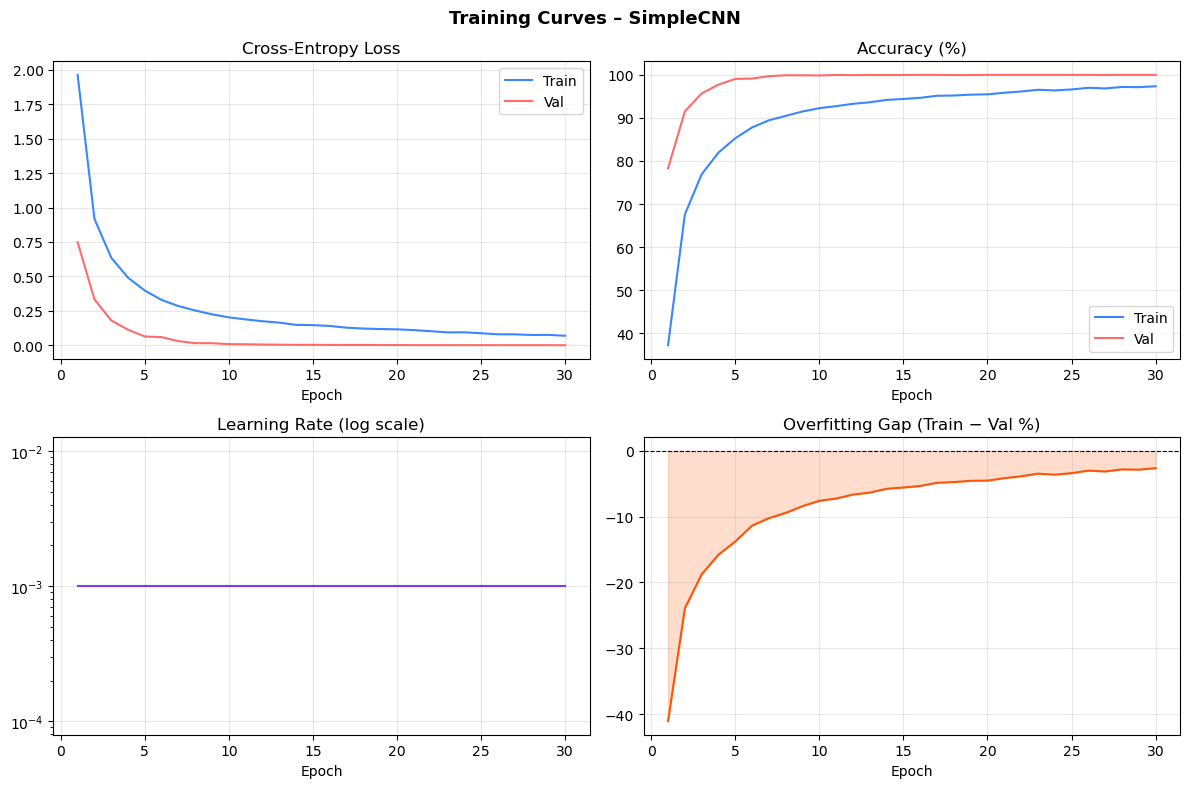

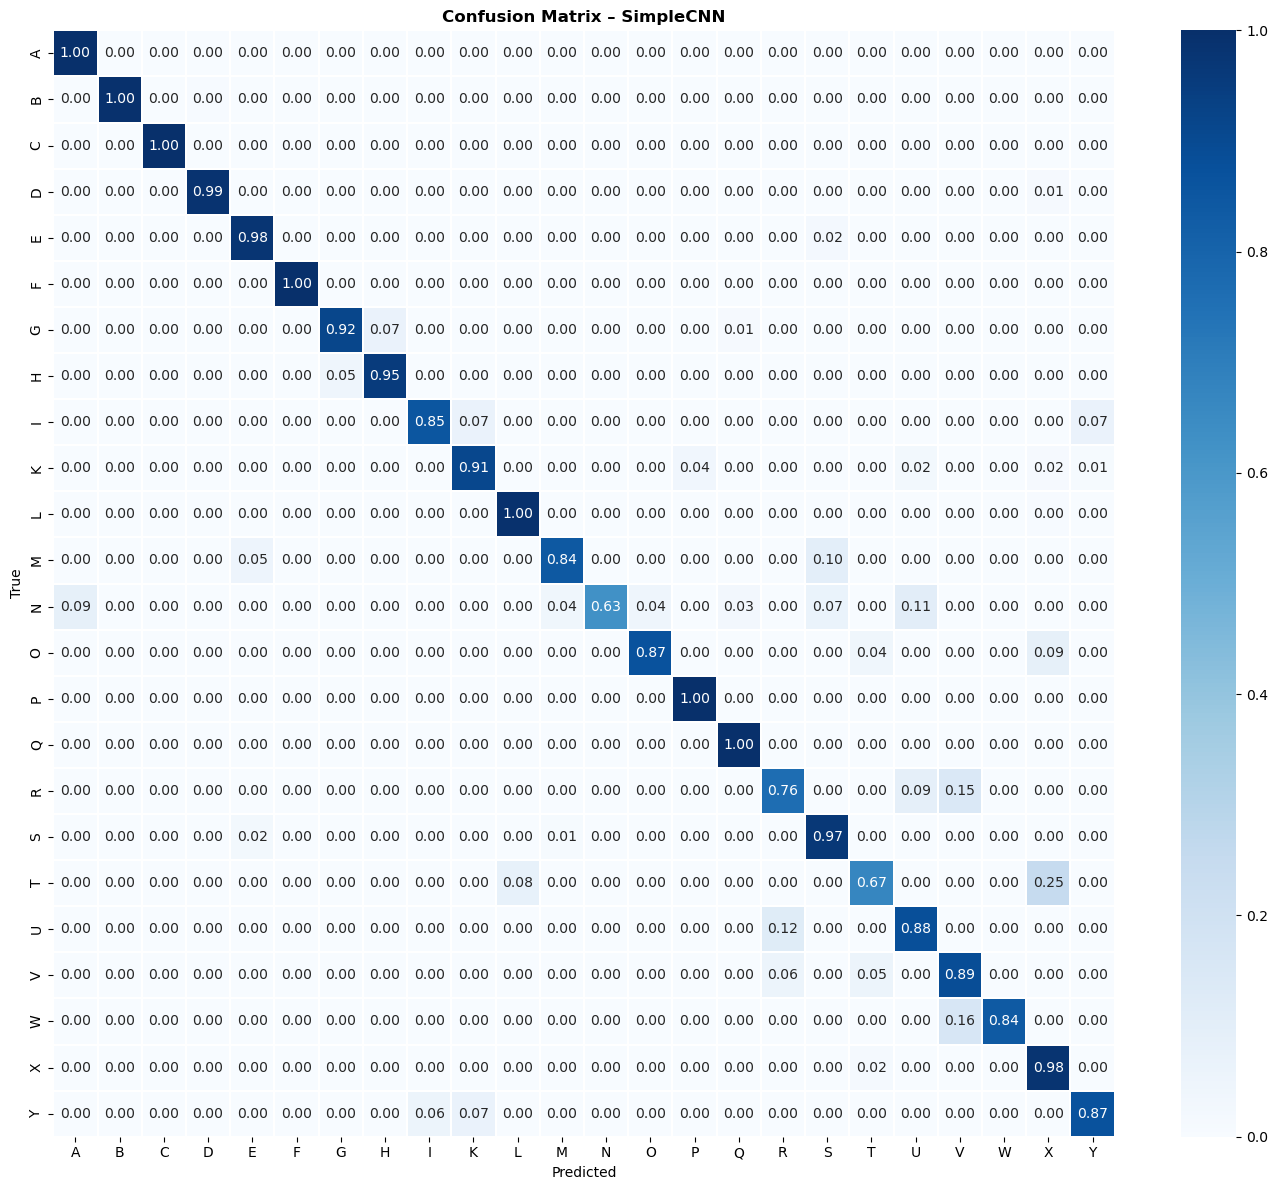

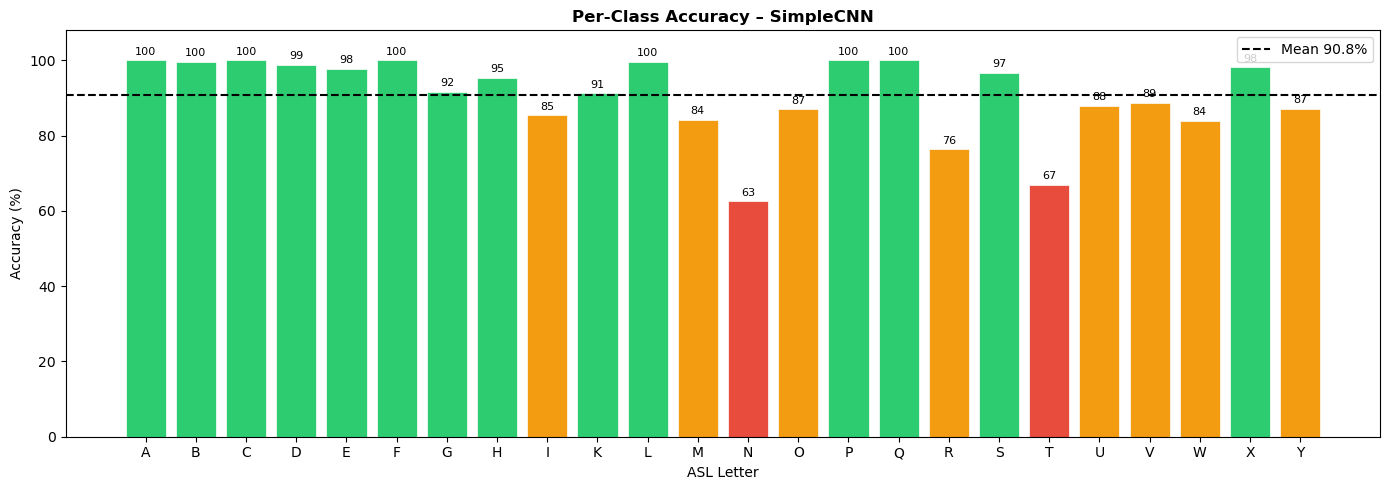

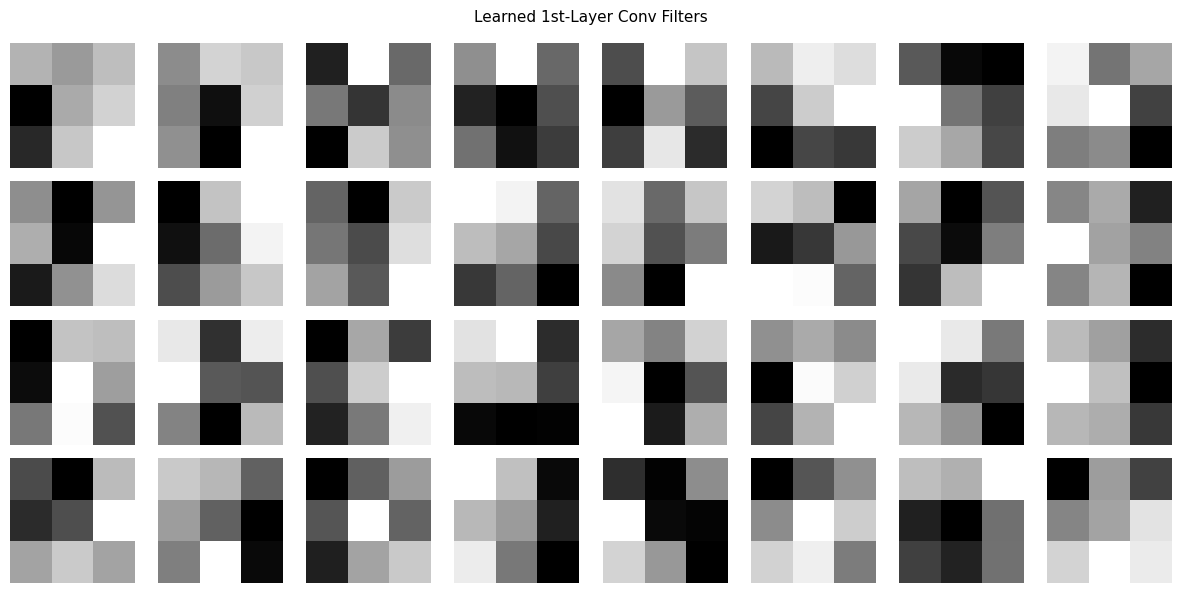


  Running: DeepCNN

  Training [DeepCNN] for 30 epochs on cpu …
    Ep   1/30  tr_loss=1.4376 tr_acc=55.8%  vl_loss=0.3129 vl_acc=92.8%  lr=1.00e-03
    Ep   5/30  tr_loss=0.0514 tr_acc=98.6%  vl_loss=0.0014 vl_acc=100.0%  lr=1.00e-03
    Ep  10/30  tr_loss=0.0215 tr_acc=99.4%  vl_loss=0.0095 vl_acc=99.7%  lr=1.00e-03
    Ep  15/30  tr_loss=0.0062 tr_acc=99.9%  vl_loss=0.0000 vl_acc=100.0%  lr=5.00e-04
    Ep  20/30  tr_loss=0.0084 tr_acc=99.8%  vl_loss=0.0011 vl_acc=100.0%  lr=5.00e-04
    Ep  25/30  tr_loss=0.0027 tr_acc=100.0%  vl_loss=0.0000 vl_acc=100.0%  lr=2.50e-04
    Ep  30/30  tr_loss=0.0038 tr_acc=99.9%  vl_loss=0.0001 vl_acc=100.0%  lr=2.50e-04
  → Best val acc: 100.00%
  Final TEST accuracy [DeepCNN]: 99.33%


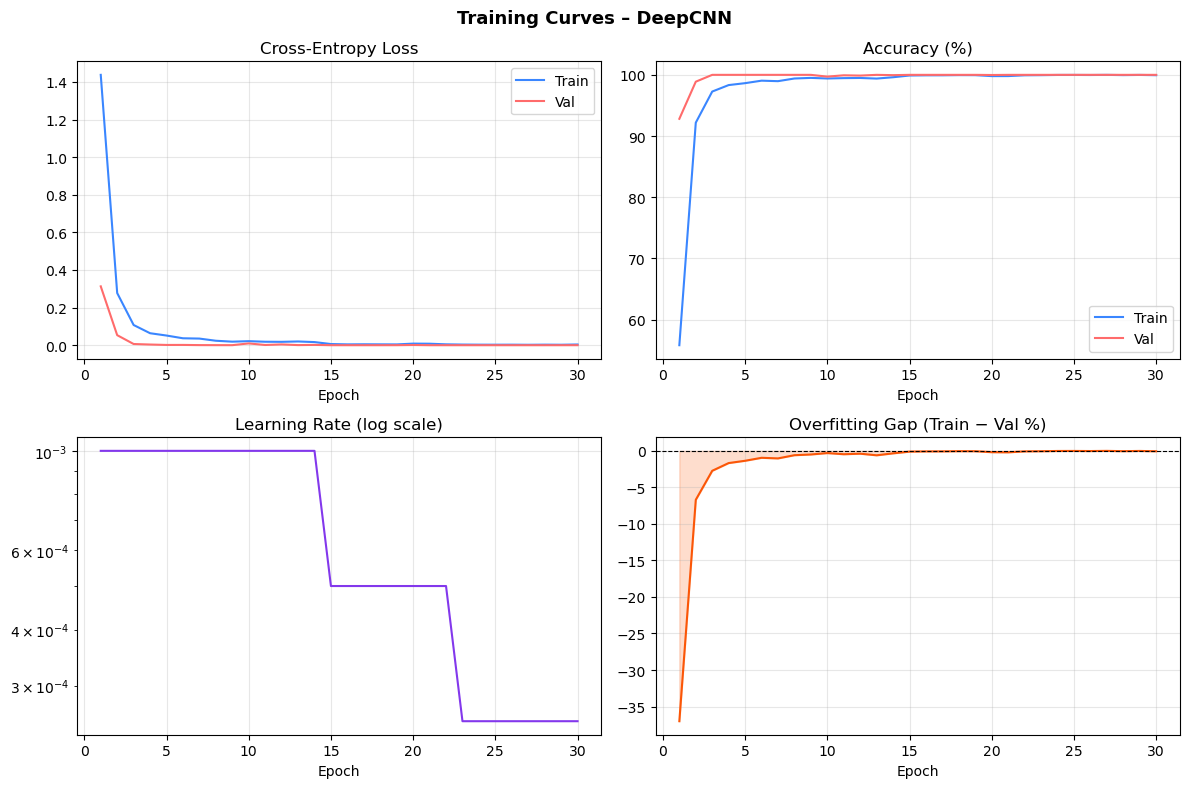

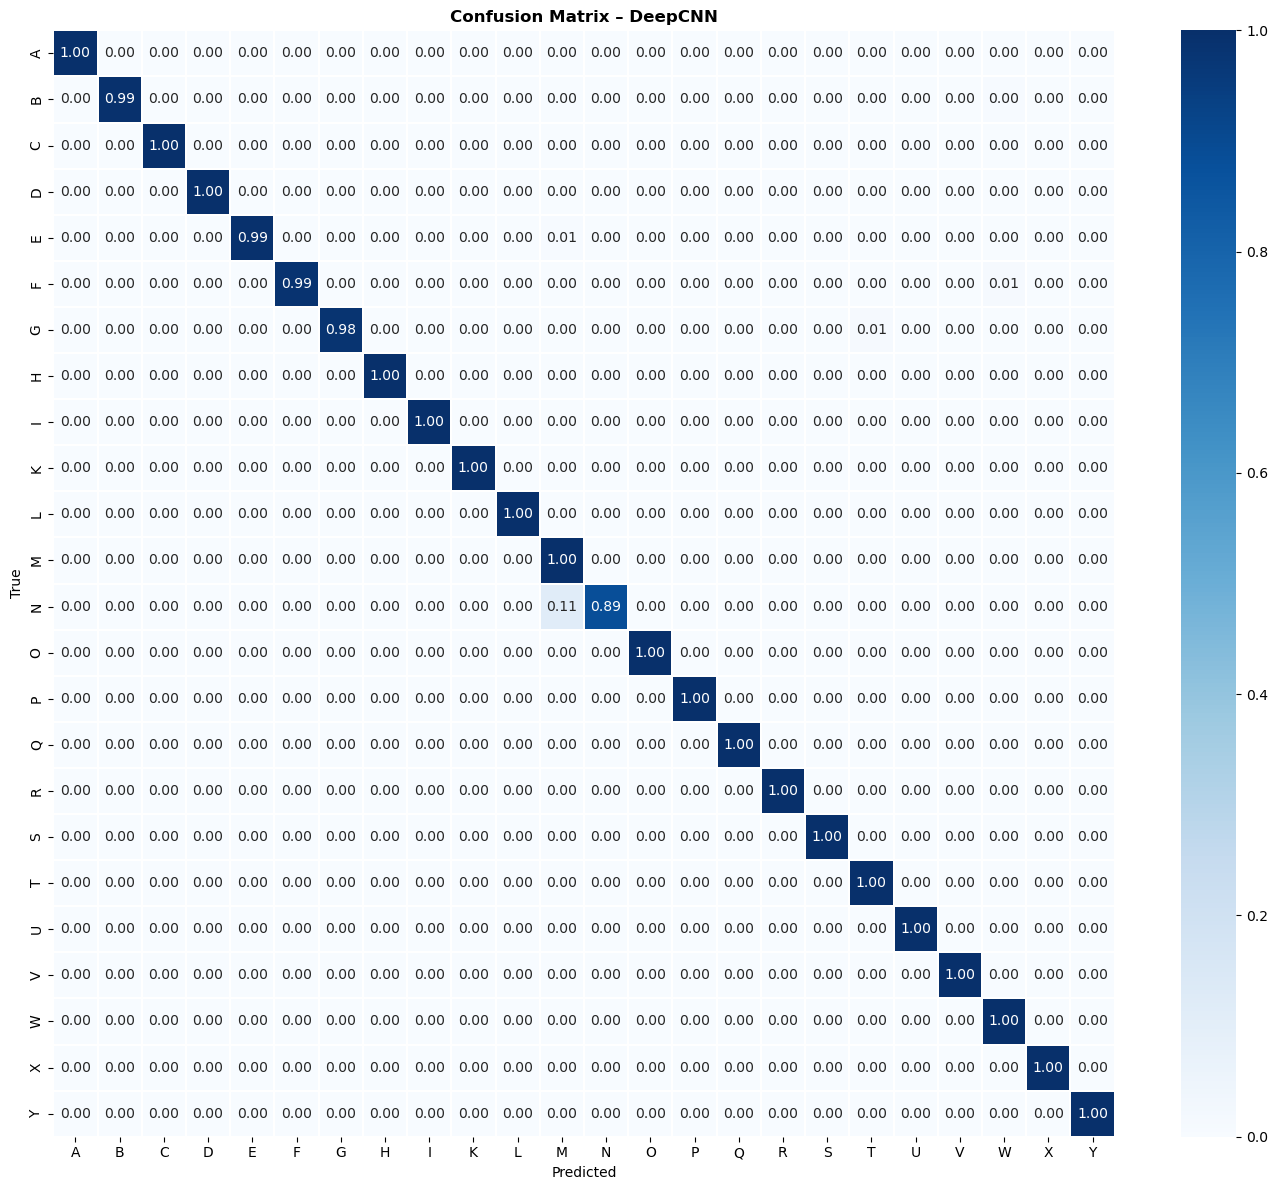

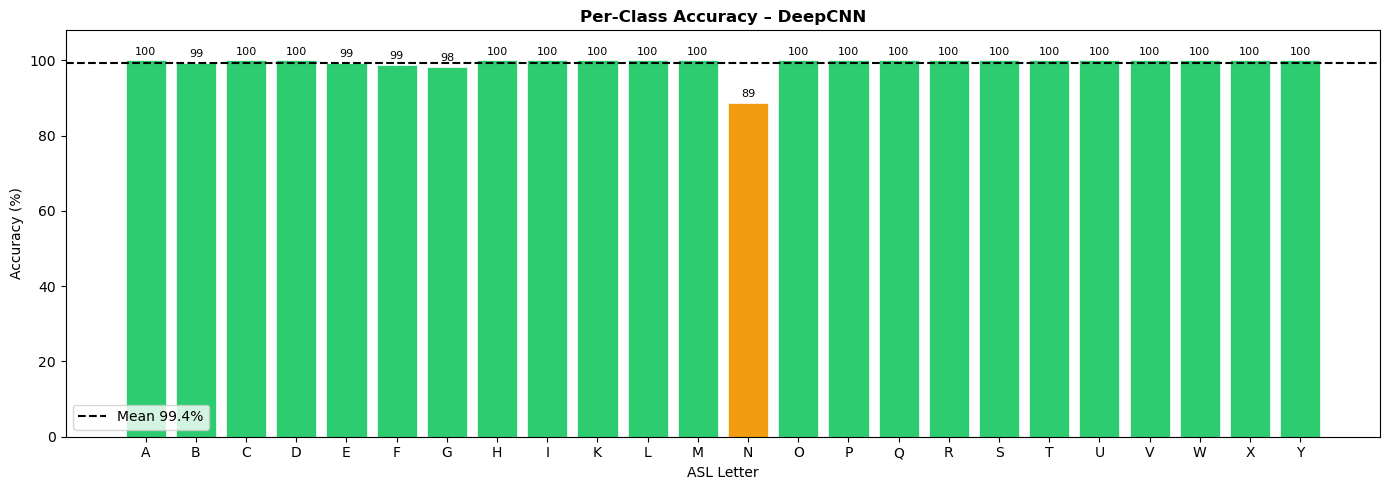

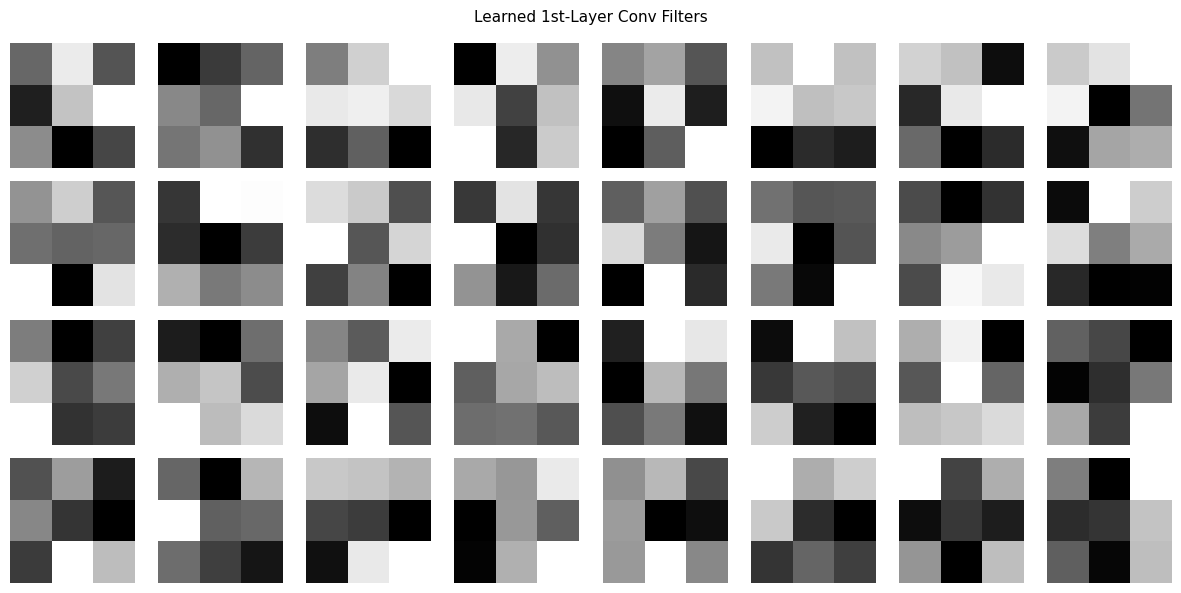


  Running: ResNetSmall

  Training [ResNetSmall] for 30 epochs on cpu …
    Ep   1/30  tr_loss=0.8170 tr_acc=78.7%  vl_loss=0.0428 vl_acc=99.9%  lr=1.00e-03
    Ep   5/30  tr_loss=0.0280 tr_acc=99.5%  vl_loss=0.0004 vl_acc=100.0%  lr=1.00e-03
    Ep  10/30  tr_loss=0.0055 tr_acc=100.0%  vl_loss=0.0002 vl_acc=100.0%  lr=1.00e-03
    Ep  15/30  tr_loss=0.0191 tr_acc=99.5%  vl_loss=0.0001 vl_acc=100.0%  lr=1.00e-03
    Ep  20/30  tr_loss=0.0014 tr_acc=100.0%  vl_loss=0.0001 vl_acc=100.0%  lr=1.00e-03
    Ep  25/30  tr_loss=0.0057 tr_acc=100.0%  vl_loss=0.0001 vl_acc=100.0%  lr=5.00e-04
    Ep  30/30  tr_loss=0.0012 tr_acc=100.0%  vl_loss=0.0001 vl_acc=100.0%  lr=2.50e-04
  → Best val acc: 100.00%
  Final TEST accuracy [ResNetSmall]: 99.99%


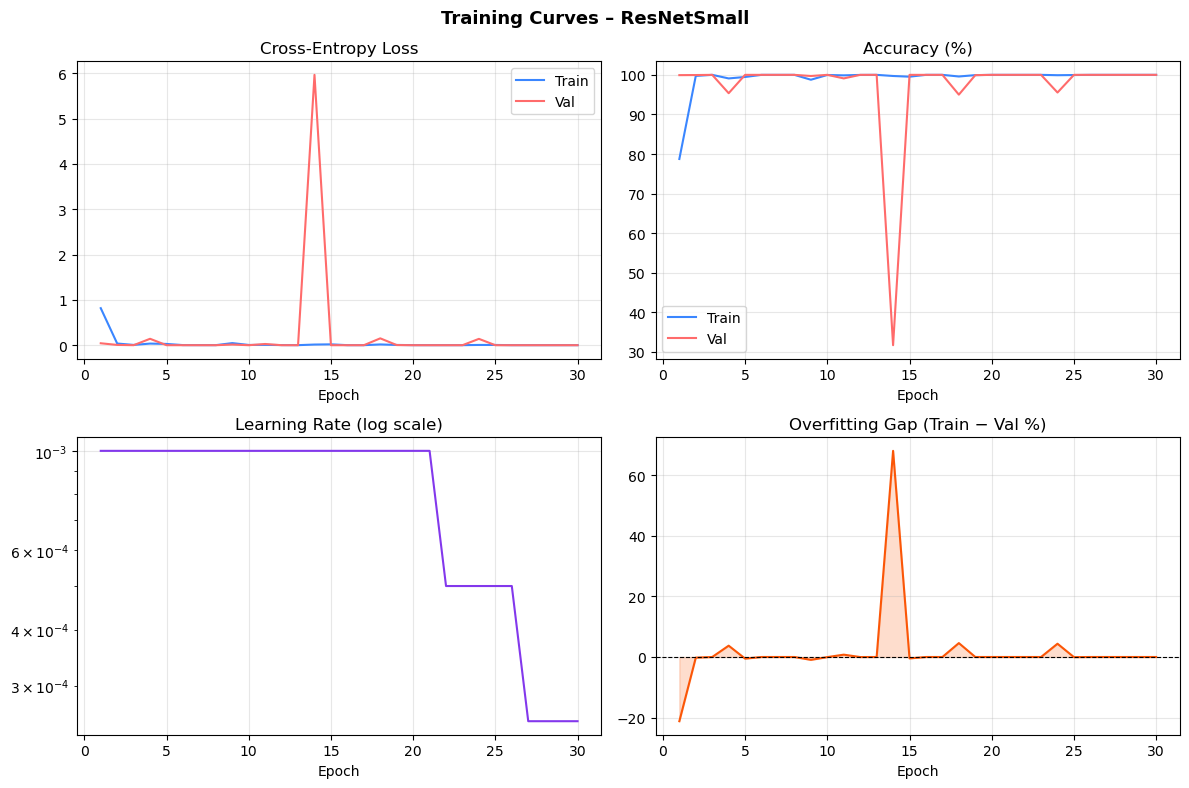

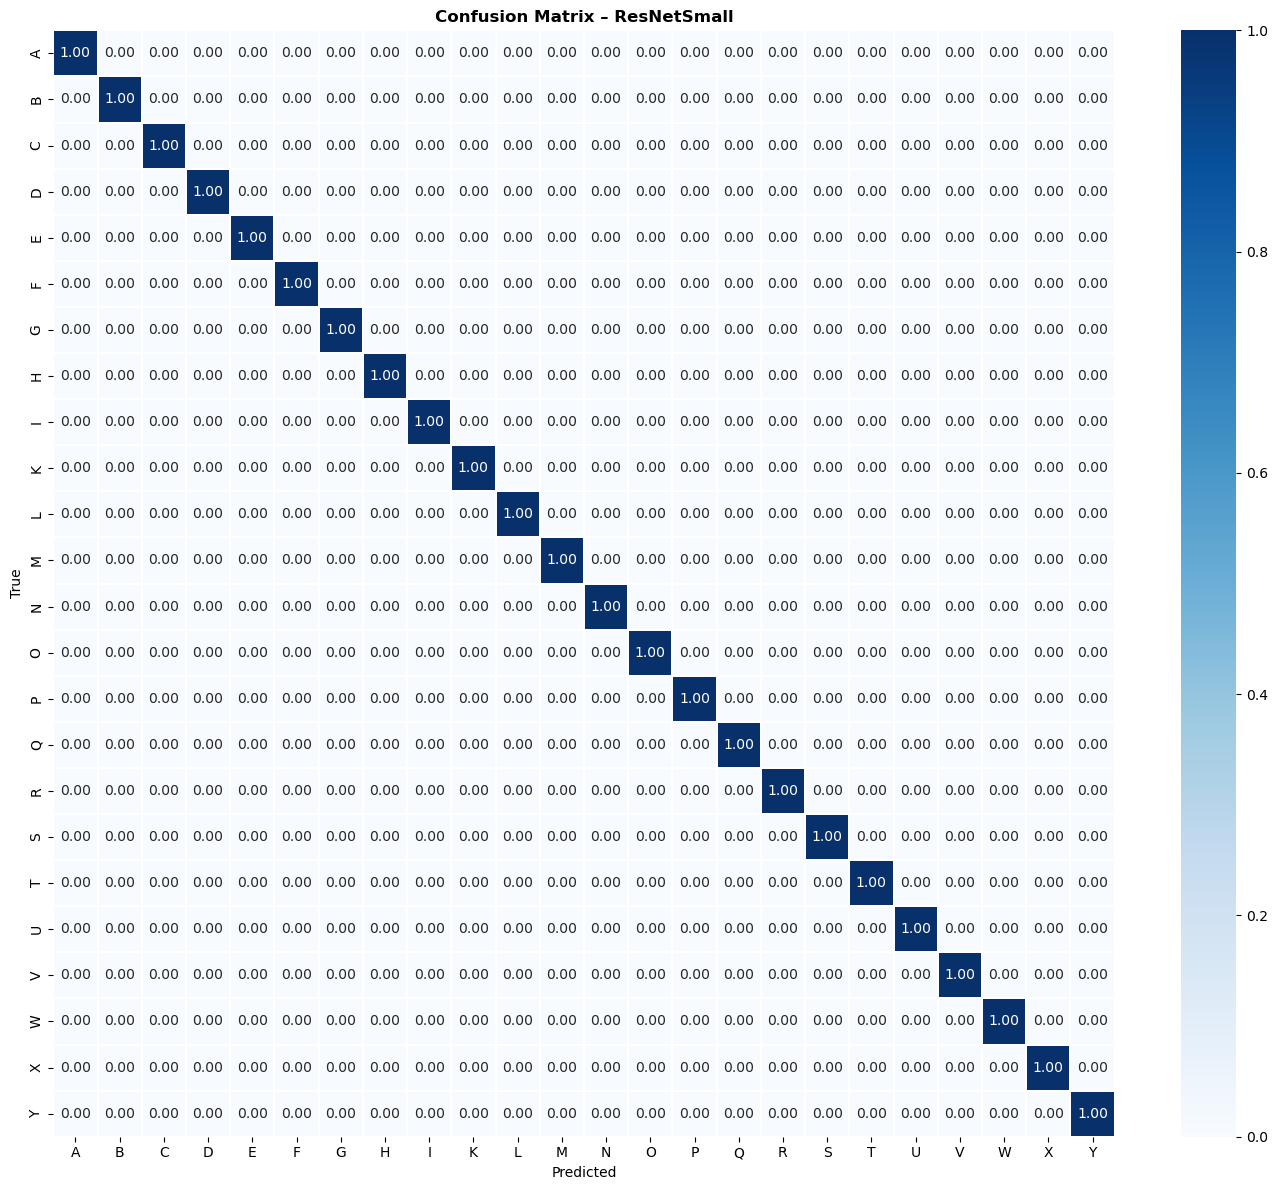

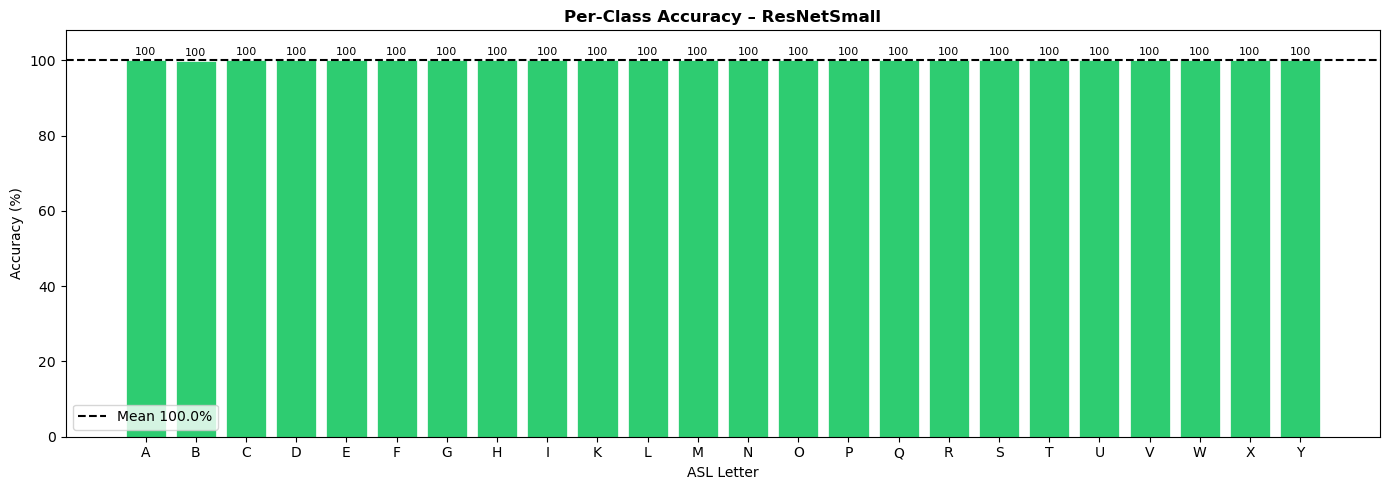

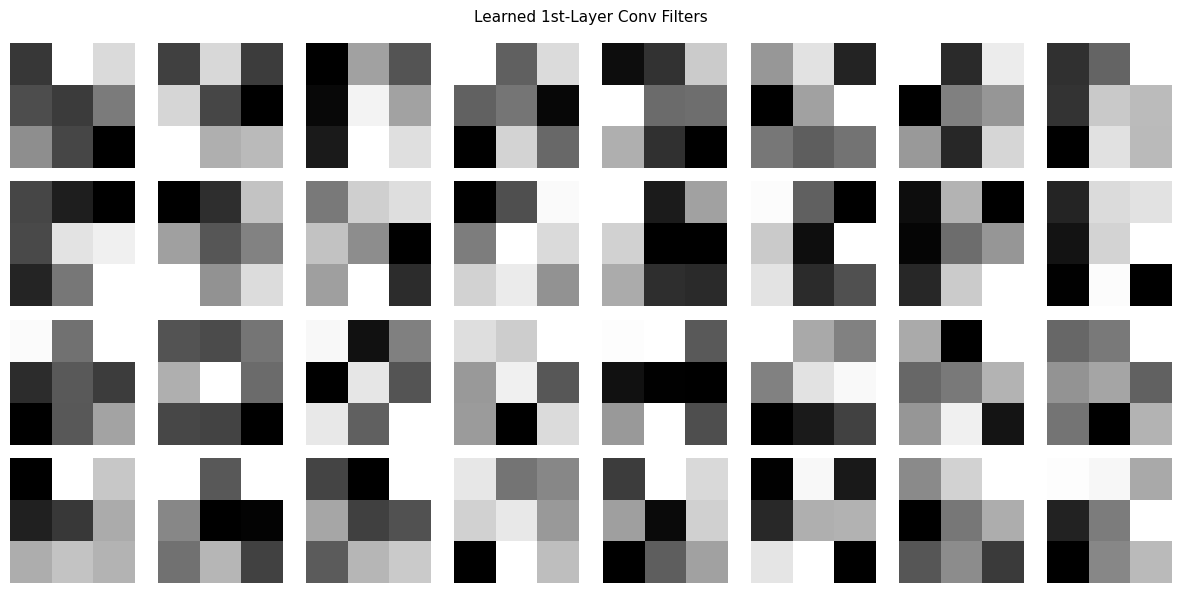


  Running: CNN_LSTM

  Training [CNN_LSTM] for 30 epochs on cpu …
    Ep   1/30  tr_loss=0.9443 tr_acc=71.3%  vl_loss=0.2236 vl_acc=93.8%  lr=1.00e-03
    Ep   5/30  tr_loss=0.0102 tr_acc=99.7%  vl_loss=0.1895 vl_acc=93.9%  lr=1.00e-03
    Ep  10/30  tr_loss=0.0300 tr_acc=99.1%  vl_loss=0.0785 vl_acc=98.0%  lr=1.00e-03
    Ep  15/30  tr_loss=0.0528 tr_acc=98.3%  vl_loss=0.0270 vl_acc=99.1%  lr=1.00e-03
    Ep  20/30  tr_loss=0.0007 tr_acc=100.0%  vl_loss=0.0001 vl_acc=100.0%  lr=1.00e-03
    Ep  25/30  tr_loss=0.0005 tr_acc=100.0%  vl_loss=0.0001 vl_acc=100.0%  lr=5.00e-04
    Ep  30/30  tr_loss=0.0017 tr_acc=100.0%  vl_loss=0.0002 vl_acc=100.0%  lr=2.50e-04
  → Best val acc: 100.00%
  Final TEST accuracy [CNN_LSTM]: 93.93%


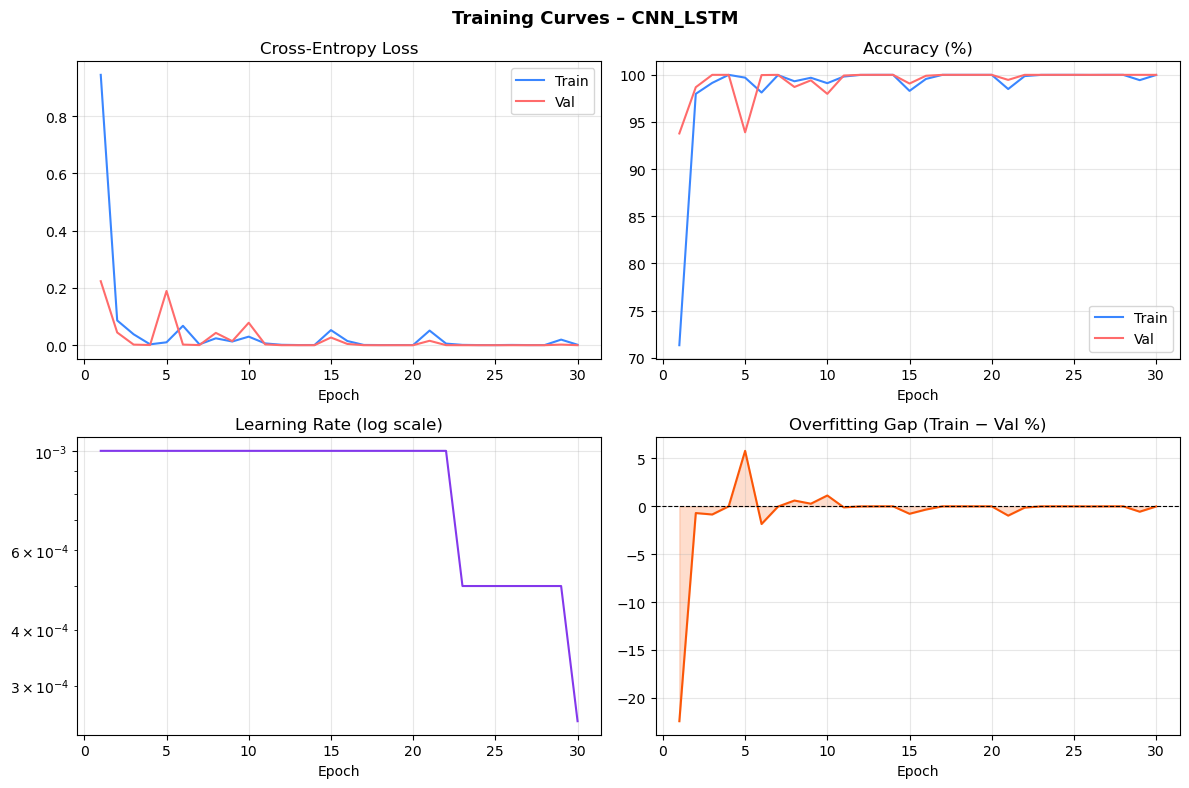

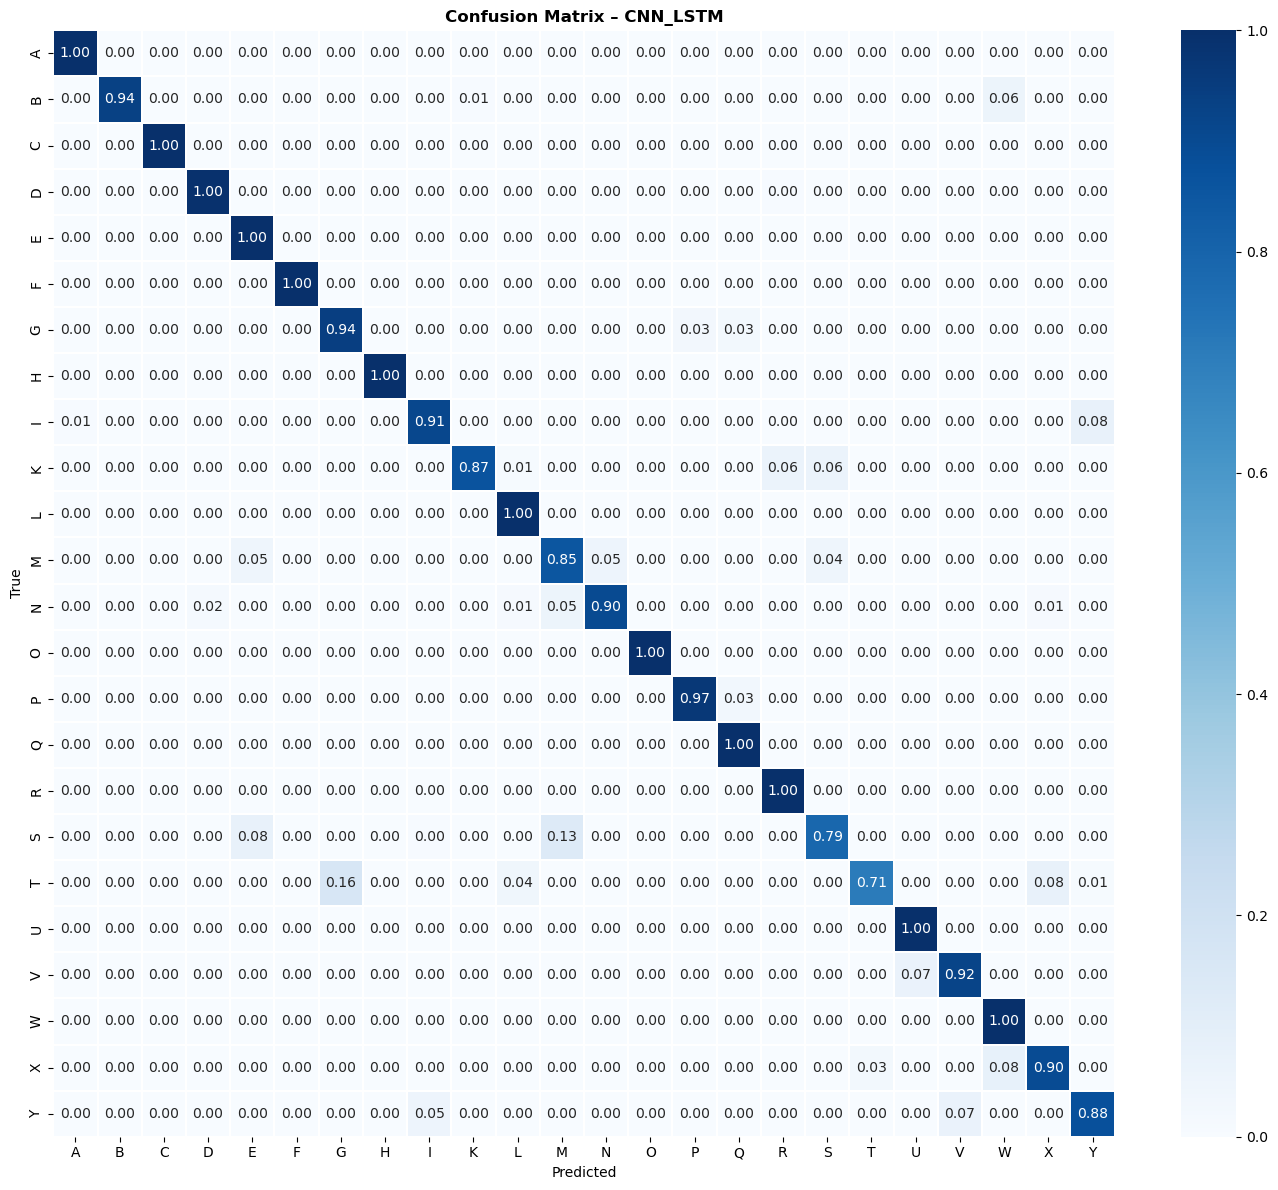

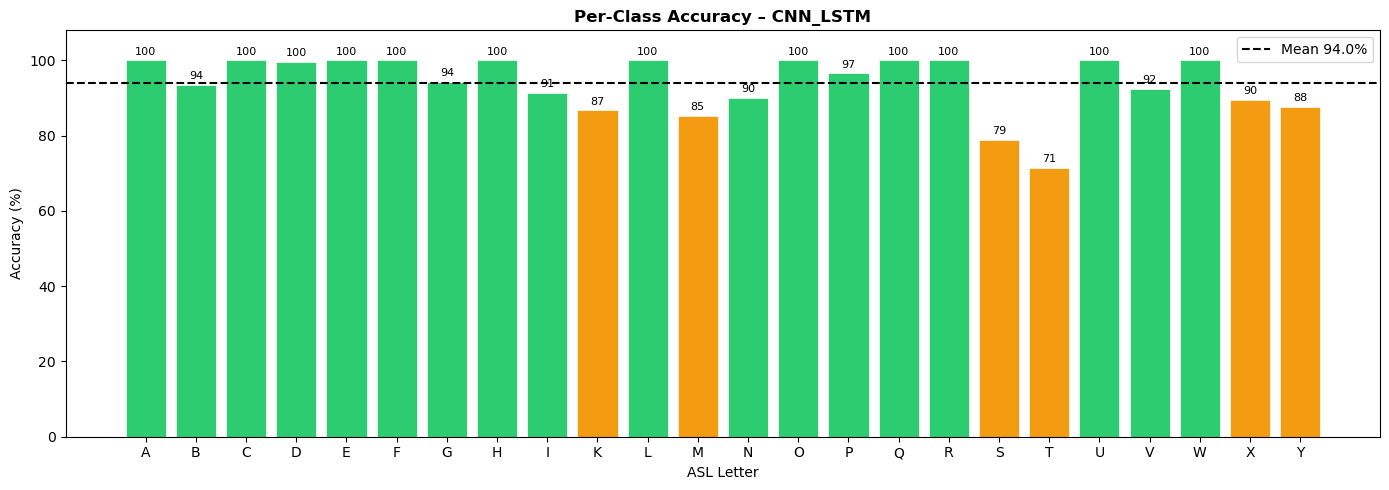

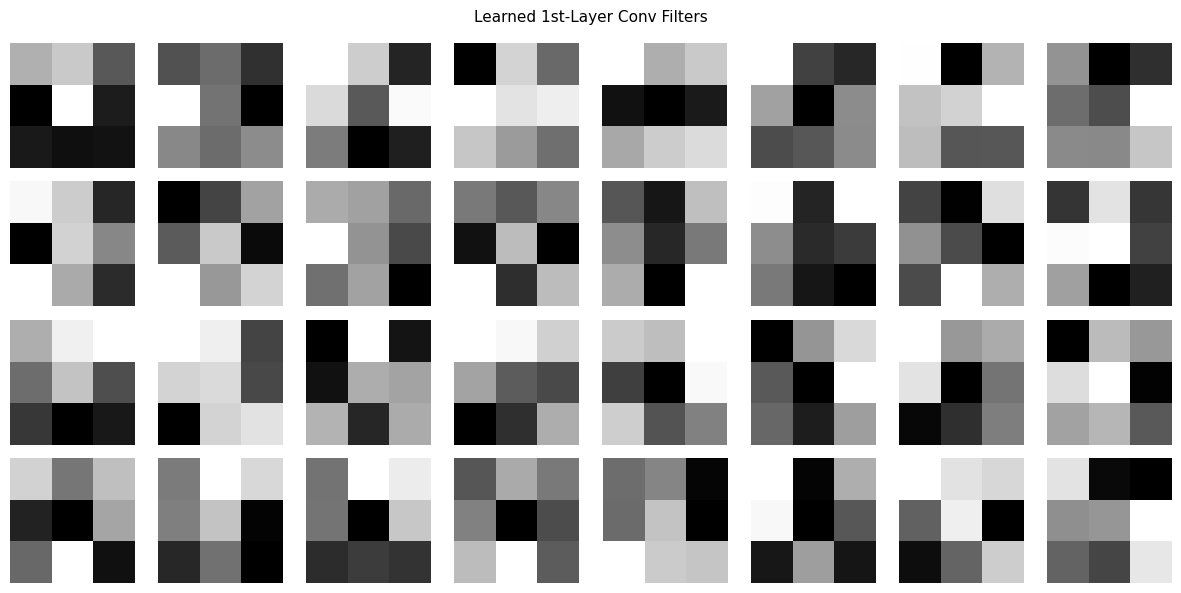

In [20]:

# ============================================================
# CELL 9 – EXPERIMENT 1: Architecture Comparison
# Same hyper-params for all; only architecture differs.
# Goal: isolate the contribution of architecture choices.
# ============================================================
arch_models = {
    "SimpleCNN":   SimpleCNN(NUM_CLASSES),
    "DeepCNN":     DeepCNN(NUM_CLASSES),
    "ResNetSmall": ResNetSmall(NUM_CLASSES),
    "CNN_LSTM":    CNN_LSTM(NUM_CLASSES),
}

for name, model_obj in arch_models.items():
    print(f"\n{'='*55}")
    print(f"  Running: {name}")
    print(f"{'='*55}")
    m, hist, preds, true, acc = run_experiment(
        model_obj, name,
        num_epochs=30, batch_size=64, lr=1e-3, weight_decay=1e-4
    )
    all_results[name] = acc
    plot_training_curves(hist, name, f"figures/curves_{name}.png")
    plot_confusion_matrix(true, preds,
                          f"Confusion Matrix – {name}",
                          f"figures/confmat_{name}.png")
    plot_per_class_accuracy(true, preds,
                             f"Per-Class Accuracy – {name}",
                             f"figures/perclass_{name}.png")
    visualise_conv_filters(m, f"figures/filters_{name}.png")
